# HS300 Bollinger Regime Analysis

## Research Objective
This notebook evaluates the predictive value, stability, and portfolio-construction usefulness of the **HS300 Bollinger-band regime filter** inside the Dynamic Mean Reversion & Multi-Factor Flow Alpha framework. The focus is whether benchmark regime recognition helps the strategy allocate a more appropriate holding count across risk-on, neutral, and defensive environments.


## Factor Definition
The regime filter is built from the same rule used in the strategy code:

- Use the latest **20-day moving average** and **20-day rolling standard deviation** of `000300.XSHG`
- Classify the benchmark as:
  - **Up Regime**: close > upper band
  - **Down Regime**: close < lower band
  - **Neutral Regime**: otherwise
- Map regime to target holding count:
  - **Up -> 7 holdings**
  - **Neutral -> 5 holdings**
  - **Down -> 3 holdings**

## Research Hypothesis
The working hypothesis is that the benchmark Bollinger state contains useful market-context information. If the hypothesis is correct, the strategy stock pool should show systematically different forward returns under Up / Neutral / Down conditions, which would justify dynamic capacity adjustment rather than keeping a fixed portfolio size.

## Data and Test Design
The regime filter is tested on the strategy's fixed 33-stock pool over **2016-01-01 to 2026-04-29**, using monthly cross-sectional snapshots aligned with the reference factor notebooks. The analysis includes cumulative regime returns, average and volatility comparison, annual regime attribution, regime frequency, benchmark band-state inspection, and return heatmap analysis.


Initiating HS300 Bollinger Regime Diagnostic...
Processing Snapshot: 2026-03-31
Data collection complete.


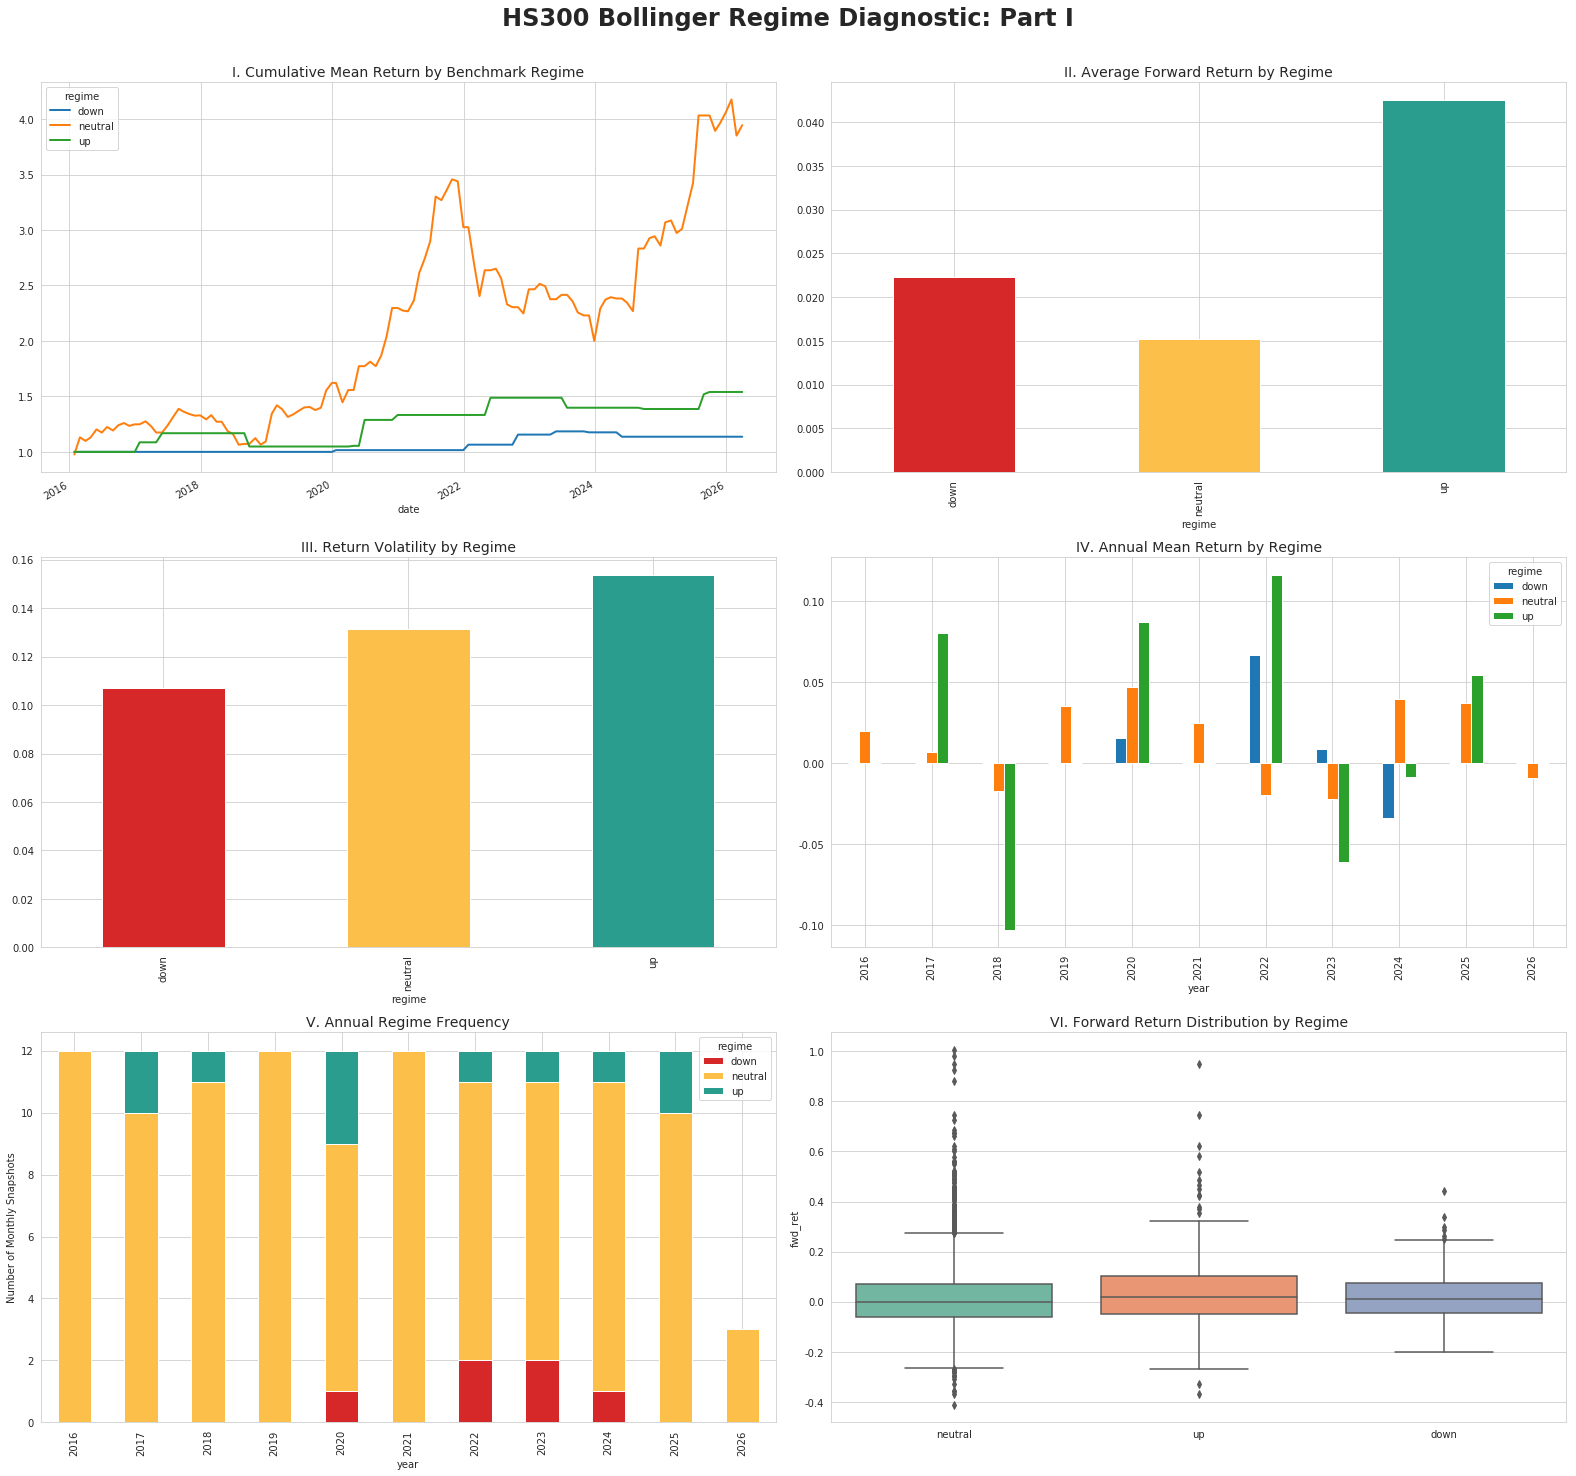

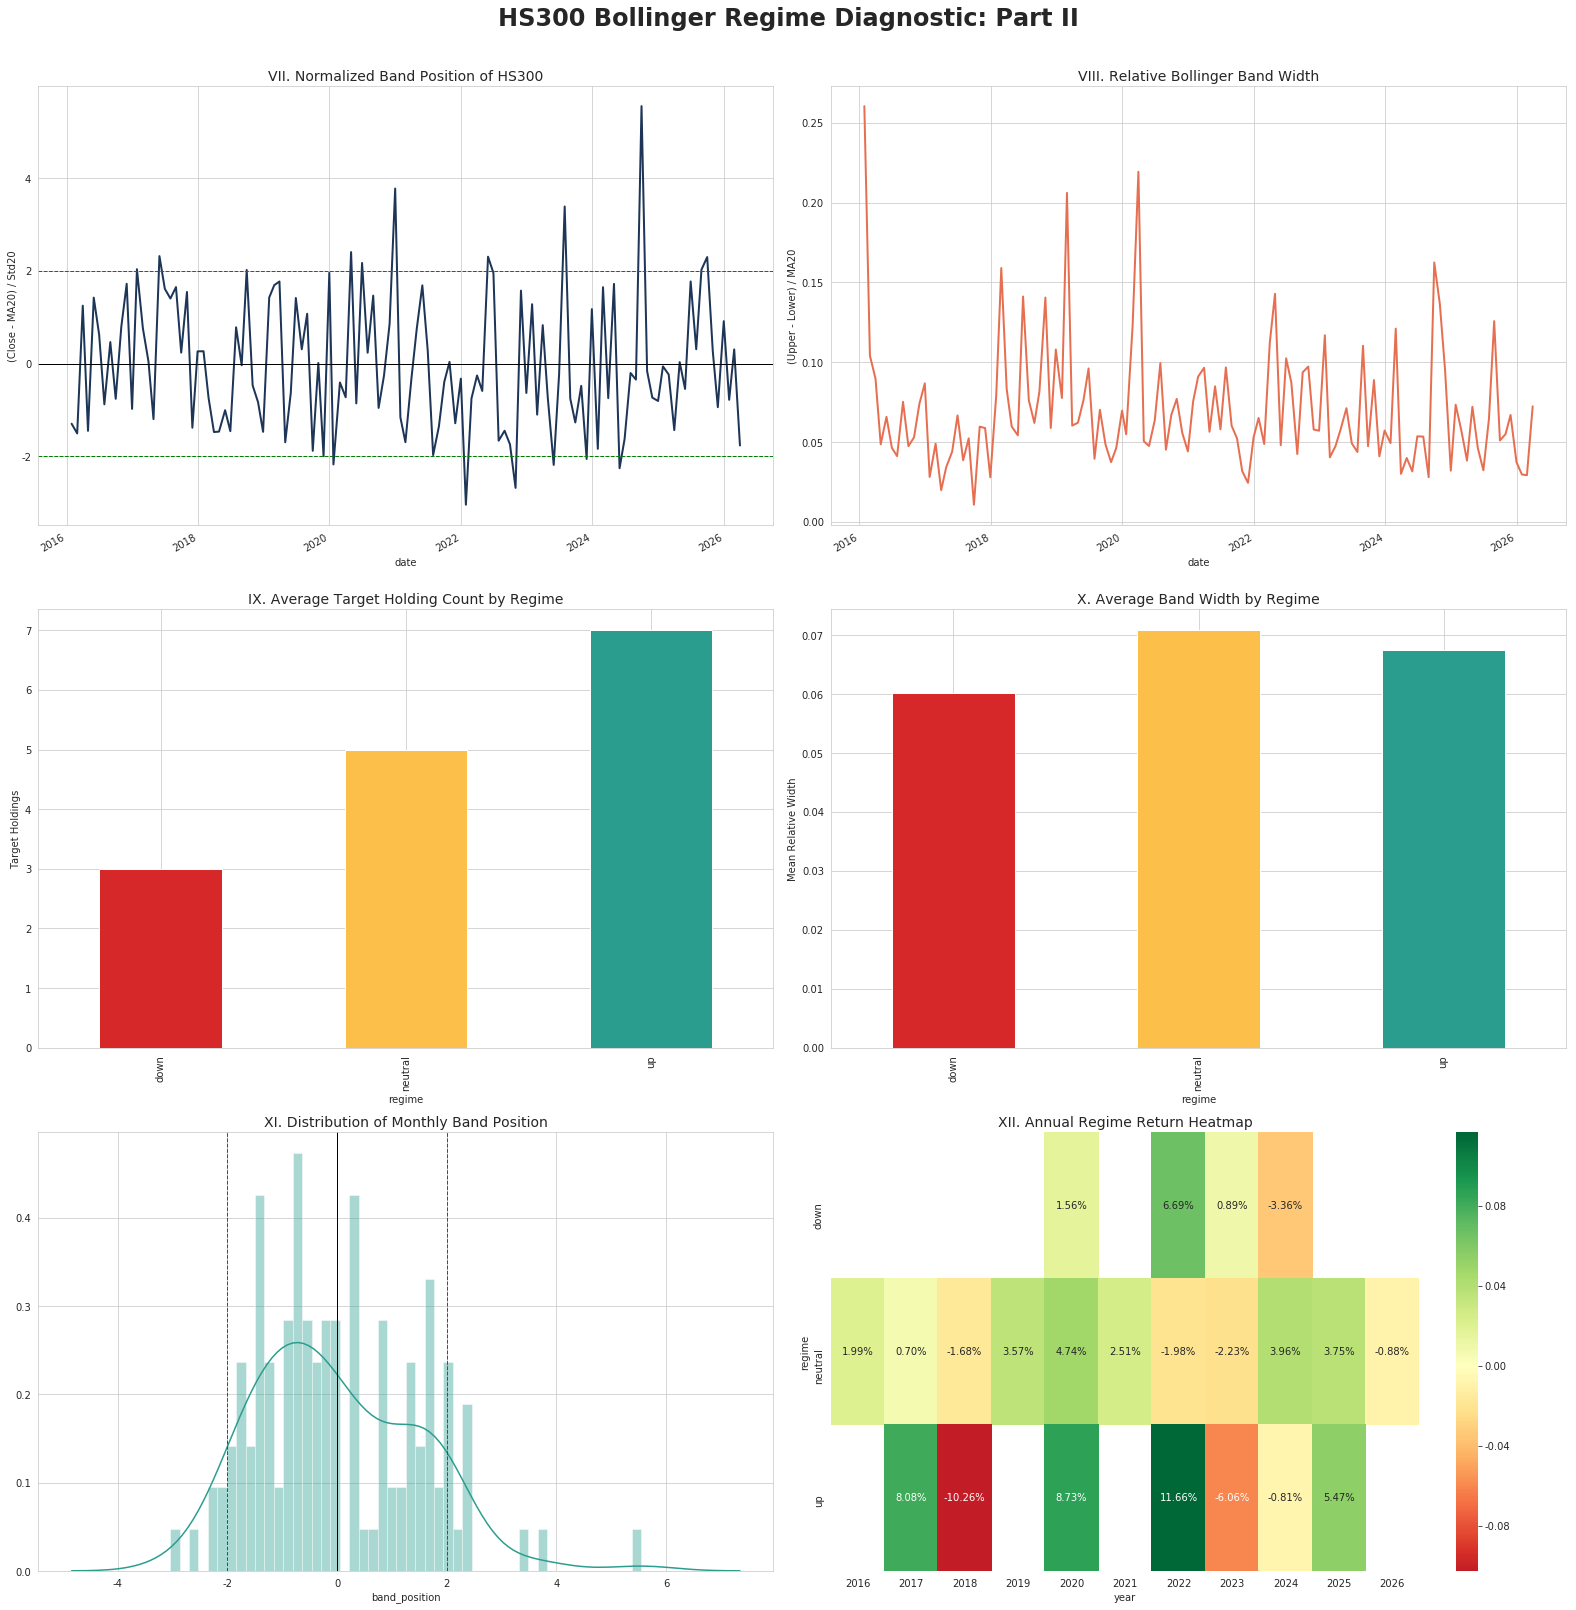


FINAL SUMMARY: HS300 BOLLINGER REGIME FILTER
------------------------------------------------------------------------------------------
        fwd_ret               target_num band_width band_position
           mean     std count       mean       mean          mean
regime                                                           
down     0.0223  0.1071   197          3     0.0602       -2.3994
neutral  0.0152  0.1315  3367          5     0.0708       -0.1568
up       0.0425  0.1535   351          7     0.0675        2.7536


In [2]:
'''
This diagnostic evaluates the HS300 Bollinger-Band regime filter used by the
Dynamic Mean Reversion & Multi-Factor Flow Alpha strategy.

Core Logic:
1. Use the latest 20-day moving average and rolling standard deviation
   to classify the benchmark into Up / Neutral / Down regimes.
2. The strategy adjusts target holdings to 7 / 5 / 3 based on this regime.
3. This script measures how the strategy stock pool performs under each regime.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jqdata import *
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

STOCK_POOL = [
    '601117.XSHG', '601600.XSHG', '601888.XSHG', '300274.XSHE', '300750.XSHE',
    '601919.XSHG', '002049.XSHE', '603881.XSHG', '002335.XSHE', '600089.XSHG',
    '002236.XSHE', '002056.XSHE', '300866.XSHE', '002611.XSHE', '600760.XSHG',
    '300693.XSHE', '002402.XSHE', '002600.XSHE', '300207.XSHE', '603486.XSHG',
    '000591.XSHE', '000027.XSHE', '600011.XSHG', '601899.XSHG', '603799.XSHG',
    '002340.XSHE', '002780.XSHE', '600160.XSHG', '601225.XSHG', '002555.XSHE',
    '600803.XSHG', '300059.XSHE', '002736.XSHE',
]

# ------------------------------------------------------------------------------
# 1. Sampling Framework
# ------------------------------------------------------------------------------
# Following the reference factor notebooks, we use monthly cross-sectional
# snapshots built from the last trading day of each month.
start_date, end_date = '2016-01-01', '2026-04-29'
all_days = get_trade_days(start_date, end_date)
ts_series = pd.to_datetime(pd.Series(all_days))
rebal_dates = ts_series.groupby([ts_series.dt.year, ts_series.dt.month]).last()
date_list = [d.strftime('%Y-%m-%d') for d in rebal_dates]

dataset = []
print('Initiating HS300 Bollinger Regime Diagnostic...')

# ------------------------------------------------------------------------------
# 2. Regime Data Collection
# ------------------------------------------------------------------------------
# For each monthly snapshot:
# - calculate HS300 20-day Bollinger structure from the strategy rule
# - classify the market into Up / Neutral / Down regime
# - measure next-period stock-pool returns under the detected regime
for i in range(len(date_list) - 1):
    t0, t1 = date_list[i], date_list[i + 1]
    print('\rProcessing Snapshot: {}'.format(t0), end='')

    bench = get_price('000300.XSHG', end_date=t0, count=21, fields=['close'], fq='pre')
    pool_px = get_price(STOCK_POOL, start_date=t0, end_date=t1, fields=['close'], panel=False, fq='pre')
    if bench is None or len(bench) < 21 or pool_px is None or pool_px.empty:
        continue

    closes = bench['close'].values
    ma = np.mean(closes[:-1])
    std = np.std(closes[:-1])
    upper = ma + 2 * std
    lower = ma - 2 * std
    current = closes[-1]

    if current > upper:
        regime = 'up'
        target_num = 7
    elif current < lower:
        regime = 'down'
        target_num = 3
    else:
        regime = 'neutral'
        target_num = 5

    for stock in STOCK_POOL:
        px = pool_px[pool_px['code'] == stock].sort_values('time')
        if len(px) < 2:
            continue

        fwd_ret = px['close'].iloc[-1] / px['close'].iloc[0] - 1.0
        band_width = (upper - lower) / ma if ma != 0 else np.nan
        band_position = (current - ma) / std if std != 0 else 0.0
        dataset.append({
            'date': t0,
            'code': stock,
            'regime': regime,
            'target_num': target_num,
            'benchmark_close': current,
            'benchmark_ma20': ma,
            'upper_band': upper,
            'lower_band': lower,
            'band_width': band_width,
            'band_position': band_position,
            'fwd_ret': fwd_ret,
        })

print('\nData collection complete.')

# ------------------------------------------------------------------------------
# 3. Master Dataset Preparation
# ------------------------------------------------------------------------------
master_df = pd.DataFrame(dataset)
master_df['date'] = pd.to_datetime(master_df['date'])
master_df['year'] = master_df['date'].dt.year

regime_ret = master_df.groupby(['date', 'regime'])['fwd_ret'].mean().reset_index()
regime_pivot = regime_ret.pivot(index='date', columns='regime', values='fwd_ret').sort_index()

summary = master_df.groupby('regime').agg({
    'fwd_ret': ['mean', 'std', 'count'],
    'target_num': 'mean',
    'band_width': 'mean',
    'band_position': 'mean',
}).round(4)

# Snapshot-level regime features:
# keep one row per monthly observation for regime frequency and benchmark state analysis.
snapshot_df = master_df.groupby('date').first().reset_index()[[
    'date', 'year', 'regime', 'target_num', 'benchmark_close',
    'benchmark_ma20', 'upper_band', 'lower_band', 'band_width', 'band_position'
]]

# ------------------------------------------------------------------------------
# 4. Visualization: Part I - Regime Return Diagnostics
# ------------------------------------------------------------------------------
fig1 = plt.figure(figsize=(22, 22))
plt.suptitle('HS300 Bollinger Regime Diagnostic: Part I', fontsize=24, fontweight='bold', y=0.96)

ax1 = plt.subplot(3, 2, 1)
(1 + regime_pivot.fillna(0)).cumprod().plot(ax=ax1, lw=2)
ax1.set_title('I. Cumulative Mean Return by Benchmark Regime', fontsize=14)

ax2 = plt.subplot(3, 2, 2)
summary['fwd_ret']['mean'].plot(kind='bar', color=['#d62828', '#fcbf49', '#2a9d8f'], ax=ax2)
ax2.set_title('II. Average Forward Return by Regime', fontsize=14)

ax3 = plt.subplot(3, 2, 3)
summary['fwd_ret']['std'].plot(kind='bar', color=['#d62828', '#fcbf49', '#2a9d8f'], ax=ax3)
ax3.set_title('III. Return Volatility by Regime', fontsize=14)

ax4 = plt.subplot(3, 2, 4)
regime_year = regime_ret.copy()
regime_year['year'] = pd.to_datetime(regime_year['date']).dt.year
regime_year.groupby(['year', 'regime'])['fwd_ret'].mean().unstack().plot(kind='bar', ax=ax4)
ax4.set_title('IV. Annual Mean Return by Regime', fontsize=14)

ax5 = plt.subplot(3, 2, 5)
regime_freq = snapshot_df.groupby(['year', 'regime']).size().unstack().fillna(0)
regime_freq.plot(kind='bar', stacked=True, ax=ax5, color=['#d62828', '#fcbf49', '#2a9d8f'])
ax5.set_title('V. Annual Regime Frequency', fontsize=14)
ax5.set_ylabel('Number of Monthly Snapshots')

ax6 = plt.subplot(3, 2, 6)
sns.boxplot(x='regime', y='fwd_ret', data=master_df, palette='Set2', ax=ax6)
ax6.set_title('VI. Forward Return Distribution by Regime', fontsize=14)
ax6.set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

# ------------------------------------------------------------------------------
# 5. Visualization: Part II - Benchmark State Attribution
# ------------------------------------------------------------------------------
fig2 = plt.figure(figsize=(22, 24))
plt.suptitle('HS300 Bollinger Regime Diagnostic: Part II', fontsize=24, fontweight='bold', y=0.96)

ax7 = plt.subplot(3, 2, 1)
snapshot_df.groupby('date')['band_position'].mean().plot(ax=ax7, color='#1d3557', lw=2)
ax7.axhline(2, color='red', linestyle='--', lw=1)
ax7.axhline(-2, color='green', linestyle='--', lw=1)
ax7.axhline(0, color='black', lw=1)
ax7.set_title('VII. Normalized Band Position of HS300', fontsize=14)
ax7.set_ylabel('(Close - MA20) / Std20')

ax8 = plt.subplot(3, 2, 2)
snapshot_df.groupby('date')['band_width'].mean().plot(ax=ax8, color='#e76f51', lw=2)
ax8.set_title('VIII. Relative Bollinger Band Width', fontsize=14)
ax8.set_ylabel('(Upper - Lower) / MA20')

ax9 = plt.subplot(3, 2, 3)
summary['target_num']['mean'].plot(kind='bar', color=['#d62828', '#fcbf49', '#2a9d8f'], ax=ax9)
ax9.set_title('IX. Average Target Holding Count by Regime', fontsize=14)
ax9.set_ylabel('Target Holdings')

ax10 = plt.subplot(3, 2, 4)
summary['band_width']['mean'].plot(kind='bar', color=['#d62828', '#fcbf49', '#2a9d8f'], ax=ax10)
ax10.set_title('X. Average Band Width by Regime', fontsize=14)
ax10.set_ylabel('Mean Relative Width')

ax11 = plt.subplot(3, 2, 5)
if hasattr(sns, 'distplot'):
    sns.distplot(snapshot_df['band_position'].dropna(), bins=50, color='#2a9d8f', ax=ax11)
else:
    ax11.hist(snapshot_df['band_position'].dropna(), bins=50, color='#2a9d8f', alpha=0.85)
ax11.axvline(0, color='black', lw=1)
ax11.axvline(2, color='red', linestyle='--', lw=1)
ax11.axvline(-2, color='green', linestyle='--', lw=1)
ax11.set_title('XI. Distribution of Monthly Band Position', fontsize=14)

ax12 = plt.subplot(3, 2, 6)
heat_df = regime_year.groupby(['year', 'regime'])['fwd_ret'].mean().unstack()
sns.heatmap(heat_df.T, annot=True, fmt='.2%', cmap='RdYlGn', center=0, ax=ax12)
ax12.set_title('XII. Annual Regime Return Heatmap', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

# ------------------------------------------------------------------------------
# 6. Summary Output
# ------------------------------------------------------------------------------
print('\n' + '=' * 90)
print('FINAL SUMMARY: HS300 BOLLINGER REGIME FILTER')
print('-' * 90)
print(summary)
print('=' * 90)


## Interpretation of Current Results
Based on the latest notebook output, the regime filter currently shows:

- **Up Regime Mean Forward Return: 4.25%**
- **Neutral Regime Mean Forward Return: 1.52%**
- **Down Regime Mean Forward Return: 2.23%**
- **Target Holding Mapping:** Up = 7, Neutral = 5, Down = 3
- **Average Band Position:** Up = 2.75, Neutral = -0.16, Down = -2.40

### Practical Reading
This is a **more useful result set** than a weak standalone technical timing factor. The benchmark regime filter clearly separates a strong risk-on state from the neutral background: the **Up regime** produces meaningfully higher forward returns than the Neutral regime, which supports the strategy's decision to raise portfolio capacity when the market breaks above its upper Bollinger band.

### Risk-Control Interpretation
The **Down regime** does not collapse into negative returns in this sample, but it still represents a deeply negative band-position environment and is associated with a much smaller target holding count. That means the signal is probably more useful as a **position-sizing and exposure-control tool** than as a hard market-timing sell signal. In other words, reducing capacity in the Down regime remains reasonable even if the average next-period return is not uniformly poor.

### Sample Structure Caveat
The Neutral regime dominates the sample, while Up and Down regimes occur far less often. This imbalance means the extreme-state return estimates are informative but should still be treated with some caution, especially when extending conclusions to different volatility cycles or future market structures.

### Research Conclusion
At the current stage, the HS300 Bollinger regime filter looks like a **credible portfolio-capacity adjustment factor**. It appears better suited to **dynamic exposure scaling** than to binary market timing, and its strongest contribution is likely the ability to help the strategy become more aggressive in confirmed upside conditions while remaining more selective in stressed environments.
